<a href="https://colab.research.google.com/github/Vixuz144/Simulacion-1/blob/main/Servidor_avanzando_eventos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# #Simulacion de lineas de espera "avanzando sobre usuarios" (anteriormente avanzando sobre eventos)
# from random import random
# from math import log
# n=100 #cantidad de usuarios
# l_l= 1
# l_s=2
# tl= 0 #tiempo de llegada del usuario actual
# tis=0 #tiempo en el que se empieza a atender
# ts= tis-(1/l_s)*log(random()) # tiempo de salida del ususario actual
# sum = ts-tl
# for i in range (n):
#     # print(round(i, 4), '\t', round(tis, 4), '\t', round(ts, 4))
#     tl= tl - (1/l_l)*log(random())
#     tis=max(tl,ts)
#     ts= tis - (1/l_s)*log(random())
#     sum = sum+ ts - tl
# print(sum/n)

In [ ]:
from random import random
import numpy as np
from numba import jit
import matplotlib.pyplot as plt

In [ ]:
@jit(nopython = True)
def LE_sucesos(n = 100, ll = 1, ls = 2):
  tl, tis = 0, 0
  ts = tis - np.log(random())/ls

  med = ts - tl
  for i in range(n):
    # print(round(i, 4), '\t', round(tis, 4), '\t', round(ts, 4))
    tl = tl - np.log(random())/ll
    tis = max(tl, ts)
    ts = tis - np.log(random())/ls
    med = med + ts - tl
  return med/n, max(tl,ts)

0.9896998306437493 100.98907459866147


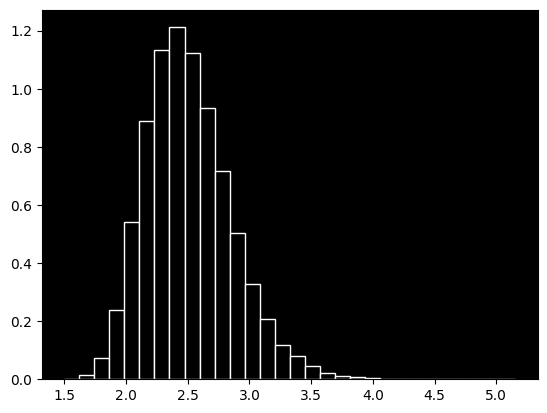

In [ ]:
rep = 10**5
l1, l2 = [], []
for i in range(rep):
  a, b = LE_sucesos()
  l1.append(a)
  l2.append(b)

print(np.mean(l1), np.mean(l2))
fig, ax = plt.subplots()
ax.hist(l, density = True, bins = 30, color = 'k', edgecolor = 'w')
ax.set_facecolor('k')
plt.show()

In [ ]:
@jit(nopython = True)
def le_1s(T, ll, ls):
  t, i = 0, 0

  med_te = 0

  tl = 0
  ts = np.inf
  t = min(tl,ts)
  u = i

  l1, l2 = [], []
  n = 0
  while min(tl,ts) < T and n < 100:
    if t == tl: #Llegada
      i += 1
      n += 1
      l1.append(tl)
      tl = t - np.log(random())/ll
      if i == 1: #si es el primer cliente
        ts = t - np.log(random())/ls
        l2.append(ts)
      u += 1
    else: #Salida
      i -= 1
      if t == 0: #Se vacia
        ts = np.inf
      else:
        ts = t - np.log(random())/ls
        l2.append(ts)
    t = min(tl,ts)
    cosa = np.array(l2) - np.array(l1)
  return cosa.mean()

In [ ]:
rep = 10**5
l =[]
for i in range(rep):
  l.append(le_1s(200, 1, 2))

print(np.mean(l))
fig, ax = plt.subplots()
ax.hist(l, density = True, bins = 30, color = 'k', edgecolor = 'w')
ax.set_facecolor('k')
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Cannot unify array(int64, 1d, C) and array(float64, 1d, C) for '$254call_method.11', defined at <ipython-input-145-e0ad1ebe5272> (32)

File "<ipython-input-145-e0ad1ebe5272>", line 32:
def le_1s(T, ll, ls):
    <source elided>
    t = min(tl,ts)
    cosa = np.array(l2) - np.array(l1)
    ^

During: resolving callee type: Function(<built-in function array>)
During: typing of call at <ipython-input-145-e0ad1ebe5272> (32)


File "<ipython-input-145-e0ad1ebe5272>", line 32:
def le_1s(T, ll, ls):
    <source elided>
    t = min(tl,ts)
    cosa = np.array(l2) - np.array(l1)
    ^
